# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [1]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [2]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [3]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
now = Time.now()
print("UTC = ", format_utc(now))
print("IST = ", format_iitk(now))



UTC =  2026-09-06 14:49:58 UTC
IST =  2026-09-06 20:19:58 IST


Here, we are not using Time.now() twice because even if its in same code block by the time they run, they both would differe in milliseconds but we want them to be exact same instant not even to differ in milliseconds. That is why we are calling it only once.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [4]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
GTC_height = 2396*u.m
wavelength = 600*u.nm
coordinate_uncertainity = 5*u.mas
cadence = 10*u.min
radio_frequency = 1.4*u.GHz

print("GTC height in kilometres = ", GTC_height.to(u.km), "its original value = ", GTC_height)
print("wavelength converted to frequency = ", wavelength.to(u.THz, equivalencies = u.spectral()), "original value = ", wavelength)
print("Coordinate uncertainty in arcseconds = ", coordinate_uncertainity.to(u.arcsec), "original value = ", coordinate_uncertainity)
print("Cadence in hours = ", cadence.to(u.hour), "original value = ", cadence)
print("Radio frequency converted to wavelength = ", radio_frequency.to(u.cm, equivalencies=u.spectral()), "original value = ", radio_frequency)

GTC height in kilometres =  2.396 km its original value =  2396.0 m
wavelength converted to frequency =  499.6540966666666 THz original value =  600.0 nm
Coordinate uncertainty in arcseconds =  0.005 arcsec original value =  5.0 mas
Cadence in hours =  0.16666666666666666 h original value =  10.0 min
Radio frequency converted to wavelength =  21.413747 cm original value =  1.4 GHz


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [5]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
planning_start = Time(START_UTC, scale="utc")
print("UTC = ", format_utc(planning_start))
print("JD = ", planning_start.jd)
print("MJD = ", planning_start.mjd)
print("IST = ", format_iitk(planning_start))
planning_start_with_add = planning_start + 2.25*u.hour
print("UTC_with_add= ", format_utc(planning_start_with_add))
print("IST_with_add= ", format_iitk(planning_start_with_add))

ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
ist_datetime_to_UTC = Time(ist_datetime)
print("IST datetime is = ", ist_datetime)
print("IST datetime to UTC = ", ist_datetime_to_UTC)
difference = ist_datetime_to_UTC - planning_start
print("Difference = ", difference)
print("Difference in microseconds = ", difference.to(u.us))

UTC =  2026-08-30 12:00:00 UTC
JD =  2461283.0
MJD =  61282.5
IST =  2026-08-30 17:30:00 IST
UTC_with_add=  2026-08-30 14:15:00 UTC
IST_with_add=  2026-08-30 19:45:00 IST
IST datetime is =  2026-08-30 17:30:00+05:30
IST datetime to UTC =  2026-08-30 12:00:00
Difference =  0.0
Difference in microseconds =  0.0 us


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [6]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
ra_angle = Angle(FRB_RA_J2000)
dec_angle = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra = ra_angle, dec = dec_angle, frame = "icrs")

ra_degree = ra_angle.degree
dec_degree = dec_angle.degree
print("RA in decimal degrees = ", ra_degree)
print("Dec in decimal degrees = ", dec_degree)

sexagesimal = frb_icrs.to_string(style="hmsdms", pad=True)
print("RA and dec in sexagesimal notation = ", sexagesimal)

expected_ra = 347.2704120833
expected_dec = 48.7066410556
tolerance = 1e-8

diff_ra = abs(frb_icrs.ra.deg - expected_ra)
diff_dec = abs(frb_icrs.dec.deg - expected_dec)
print(diff_ra)
print(diff_dec)
if diff_ra < tolerance:
  print("RA matches expected value within tolerance")
else:
  print("RA does not match expected value within tolerance")

if diff_dec < tolerance:
  print("Dec matches expected value within tolerance")
else:
  print("Dec does not match expected value within tolerance")

RA in decimal degrees =  347.27041208333327
Dec in decimal degrees =  48.70664105555556
RA and dec in sexagesimal notation =  23h09m04.8989s +48d42m23.9078s
3.325340003357269e-11
4.4444448121794267e-11
RA matches expected value within tolerance
Dec matches expected value within tolerance


RA is expressed in hours minutes seconds to make the relationship between earths roation and the position of celestial sphere convinient. Dec is just like how much north or south we are moving on celestial sphere so naturally expressed in degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [7]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
frb_galactic = frb_icrs.galactic
Galactic_longitude = frb_galactic.l
Galactic_latitude = frb_galactic.b
print("Galactic longitude = ", Galactic_longitude)
print("Galactic latitude = ", Galactic_latitude)

Galactic_longitude_deg = frb_galactic.l.deg
Galactic_latitude_deg = frb_galactic.b.deg
print("Galactic longitude in degrees = ", Galactic_longitude_deg)
print("Galactic latitude in degrees = ", Galactic_latitude_deg)

frb_icrs_back = frb_galactic.transform_to("icrs")
round_trip_separation = frb_icrs.separation(frb_icrs_back).to(u.uarcsec)
print("Round trip separation = ", round_trip_separation)

Galactic longitude =  106d03m53.85878398s
Galactic latitude =  -10d47m03.03462745s
Galactic longitude in degrees =  106.06496077332801
Galactic latitude in degrees =  -10.784176285402493
Round trip separation =  0.000310733 uarcsec


The tiny non-zero residual represents numerical precision and rounding effects introduced during the coordinate transformations. It does not represent a physical displacement of the FRB; the original and transformed-back coordinates describe the same sky position to extremely high precision.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [8]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
frb_ecliptic = frb_icrs.transform_to("barycentrictrueecliptic")
ecliptic_longitude = frb_ecliptic.lon
ecliptic_latitude = frb_ecliptic.lat
print("Ecliptic longitude = ", ecliptic_longitude)
print("Ecliptic latitude = ", ecliptic_latitude)

ecliptic_longitude_deg = frb_ecliptic.lon.deg
ecliptic_latitude_deg = frb_ecliptic.lat.deg
print("Ecliptic longitude in degrees = ", ecliptic_longitude_deg)
print("Ecliptic latitude in degrees = ", ecliptic_latitude_deg)

if 0 <= frb_ecliptic.lon.deg < 360:
  print("Ecliptic longitude is valid")
else:
  print("Ecliptic longitude is not valid")

if -90 <= frb_ecliptic.lat.deg <= 90:
  print("Ecliptic latitude is valid")
else:
  print("Ecliptic latitude is not valid")

frb_icrs_back = frb_ecliptic.transform_to("icrs")
round_trip_separation = frb_icrs.separation(frb_icrs_back).to(u.uarcsec)
print("Round trip separation = ", round_trip_separation)

Ecliptic longitude =  14d24m40.27554122s
Ecliptic latitude =  48d20m49.05037481s
Ecliptic longitude in degrees =  14.411187650340095
Ecliptic latitude in degrees =  48.34695843744783
Ecliptic longitude is valid
Ecliptic latitude is valid
Round trip separation =  0 uarcsec


The ecliptic plane is the plane of Earth's orbit around the Sun or the path traced by sun on the celestial sphere over a year. The ecliptic latitude measures how far an object lies above or below this orbital plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [9]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
earlier_position = SkyCoord(ra=Angle(EARLIER_POSITION_RA, unit=u.hourangle), dec=Angle(EARLIER_POSITION_DEC, unit=u.deg), frame = "icrs")
ra1 = frb_icrs.ra.rad
dec1 = frb_icrs.dec.rad
ra2 = earlier_position.ra.rad
dec2 = earlier_position.dec.rad

cos_delta_theta = np.sin(dec1)*np.sin(dec2) + np.cos(dec1)*np.cos(dec2)*np.cos(ra2-ra1)
cos_delta_theta = np.clip(cos_delta_theta, -1, 1)
manual_separation = np.arccos(cos_delta_theta)
manual_separation_arc = (manual_separation*u.rad).to(u.arcsec)
manual_separation_milliarc = (manual_separation*u.rad).to(u.marcsec)
print("manual separation = ", manual_separation)
print("manual separation in arcseconds = ", (manual_separation*u.rad).to(u.arcsec))
print("manual separation in milliarcseconds = ", (manual_separation*u.rad).to(u.marcsec))

separation = frb_icrs.separation(earlier_position)
separation_arc = frb_icrs.separation(earlier_position).to(u.arcsec)
separation_milliarc = frb_icrs.separation(earlier_position).to(u.marcsec)
print("separation = ", frb_icrs.separation(earlier_position))
print("separation in arcseconds = ", frb_icrs.separation(earlier_position).to(u.arcsec))
print("separation in milliarcseconds = ", frb_icrs.separation(earlier_position).to(u.marcsec))

diff_sep = separation_arc - manual_separation_arc
print("Difference = ", diff_sep)


manual separation =  7.234571307653765e-06
manual separation in arcseconds =  1.4922374490540065 arcsec
manual separation in milliarcseconds =  1492.2374490540062 marcsec
separation =  0d00m01.49223973s
separation in arcseconds =  1.49224 arcsec
separation in milliarcseconds =  1492.24 marcsec
Difference =  2.27715e-06 arcsec


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [10]:
from operator import gt
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_location = EarthLocation.from_geodetic(GTC_LONGITUDE_DEG*u.deg, GTC_LATITUDE_DEG*u.deg, GTC_HEIGHT_M*u.m)
print("Geodetic longitude = ", gtc_location.lon.deg)
print("Geodetic latitude = ", gtc_location.lat.deg)
print("Geodetic height = ", gtc_location.height)

Geodetic longitude =  -17.88900000000001
Geodetic latitude =  28.758
Geodetic height =  2395.9999999997463 m


The negative sign in longitude says that the location is on the west of the Greenwich meridian.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [11]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
Q_time = Time("2026-08-31T00:00:00Z")
gtc_lst = Q_time.sidereal_time("apparent", gtc_location)
gtc_hour_angle = (gtc_lst - frb_icrs.ra).wrap_at(12*u.hourangle)
print("UTC = ", format_utc(Q_time))
print("IST = ", format_iitk(Q_time))
print("LST = ", gtc_lst)
print("Hour angle = ", gtc_hour_angle)
if gtc_hour_angle.deg > 0:
  print("Target is west of the meridian")
elif gtc_hour_angle.deg == 0:
  print("Target is at transit")
else:
  print("Target is east of the meridian")



UTC =  2026-08-31 00:00:00 UTC
IST =  2026-08-31 05:30:00 IST
LST =  21h25m12.20821623s
Hour angle =  -1h43m52.69068377s
Target is east of the meridian


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [12]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
lst_values = []
ha_values = []

for i in range(len(times)):
  gtc_lst = times[i].sidereal_time("apparent", gtc_location)
  gtc_hour_angle = (gtc_lst - frb_icrs.ra).wrap_at(12*u.hourangle)
  lst_values.append(gtc_lst)
  ha_values.append(gtc_hour_angle)
  ha_numeric = np.array([ha.to_value(u.hourangle) for ha in ha_values])
  print("Sample index = ", i)
  print("UTC = ", format_utc(times[i]))
  print("IST = ", format_iitk(times[i]))
  print("LST = ", gtc_lst)
  print("Hour angle = ", gtc_hour_angle)

transit_index = np.argmin(np.abs(ha_numeric))

print("Nearest sampled transit:")
print("Sample index =", transit_index)
print("UTC =", format_utc(times[transit_index]))
print("IST =", format_iitk(times[transit_index]))
print("LST =", lst_values[transit_index])
print("HA =", ha_values[transit_index])

Sample index =  0
UTC =  2026-08-30 12:00:00 UTC
IST =  2026-08-30 17:30:00 IST
LST =  9h23m13.93504506s
Hour angle =  10h14m09.03614506s
Sample index =  1
UTC =  2026-08-30 12:10:00 UTC
IST =  2026-08-30 17:40:00 IST
LST =  9h33m15.57772618s
Hour angle =  10h24m10.67882618s
Sample index =  2
UTC =  2026-08-30 12:20:00 UTC
IST =  2026-08-30 17:50:00 IST
LST =  9h43m17.22040734s
Hour angle =  10h34m12.32150734s
Sample index =  3
UTC =  2026-08-30 12:30:00 UTC
IST =  2026-08-30 18:00:00 IST
LST =  9h53m18.86308854s
Hour angle =  10h44m13.96418854s
Sample index =  4
UTC =  2026-08-30 12:40:00 UTC
IST =  2026-08-30 18:10:00 IST
LST =  10h03m20.50576977s
Hour angle =  10h54m15.60686977s
Sample index =  5
UTC =  2026-08-30 12:50:00 UTC
IST =  2026-08-30 18:20:00 IST
LST =  10h13m22.14845105s
Hour angle =  11h04m17.24955105s
Sample index =  6
UTC =  2026-08-30 13:00:00 UTC
IST =  2026-08-30 18:30:00 IST
LST =  10h23m23.79113237s
Hour angle =  11h14m18.89223237s
Sample index =  7
UTC =  2026-0

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [13]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_lat = gtc_location.lat
target_dec = frb_icrs.dec
h_transit_analytical = 90*u.deg - np.abs(gtc_lat - target_dec)
print("upper meridian transit in analytical= ", h_transit_analytical)

zenith_distance_analytical= 90*u.deg - h_transit_analytical
print("zenith distance analytically = ", zenith_distance_analytical)

frb_gtc_altaz = frb_icrs.transform_to(AltAz(obstime=times, location=gtc_location))
altitudes = frb_gtc_altaz.alt.to_value(u.deg)
max_alt_index = np.argmax(altitudes)
max_altitude = frb_gtc_altaz.alt[max_alt_index]

sampled_zenith_distance = 90*u.deg - max_altitude
print("largest sampled altitude = ", max_altitude)
print("largest sampled zenith distance = ", sampled_zenith_distance)

altitude_difference = (max_altitude - h_transit_analytical).to_value(u.arcsec)
zenith_distance_difference = (sampled_zenith_distance - zenith_distance_analytical).to_value(u.arcsec)
print("Difference between analytical and sampled altitude =", altitude_difference * u.arcsec)
print("Difference between analytical and sampled zenith distance =", zenith_distance_difference * u.arcsec)

upper meridian transit in analytical=  70d03m04.8922s
zenith distance analytically =  19d56m55.1078s
largest sampled altitude =  69d53m02.08616823s
largest sampled zenith distance =  20d06m57.91383177s
Difference between analytical and sampled altitude = -602.8060317737015 arcsec
Difference between analytical and sampled zenith distance = 602.8060317737015 arcsec


Analytically we calculated the exact instant at which transit happens but we have only samples in intervals of 10 min. So a transit can happen even duting the interval. Therfore the analytical and sampled value are not same.

## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [14]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
#transit_index = 82, we got from Q10
#2 hours before sampling = 120 minutes, our interval is 10min so 120/10 = 12 samples before and after transit index.
indices = [transit_index - 12, transit_index, transit_index + 12]

for i in indices:
  H = ha_values[i]
  sin_alt = (np.sin(gtc_lat) * np.sin(target_dec) + np.cos(gtc_lat) * np.cos(target_dec) * np.cos(H))
  calculated_alt = np.arcsin(sin_alt)
  astropy_altitude = frb_gtc_altaz.alt[i]
  difference = (astropy_altitude - calculated_alt).to_value(u.arcsec)
  print("\nSample index =", i)
  print("UTC =", format_utc(times[i]))
  print("IST =", format_iitk(times[i]))
  print("Hour angle =", H)
  print("Calculated altitude =", calculated_alt)
  print("Astropy altitude =", astropy_altitude)
  print("Difference =", difference, "arcsec")


Sample index = 70
UTC = 2026-08-30 23:40:00 UTC
IST = 2026-08-31 05:10:00 IST
Hour angle = -2h03m55.97605409s
Calculated altitude = 1.0303018680725582 rad
Astropy altitude = 58d46m53.67263948s
Difference = -901.34255453234 arcsec

Sample index = 82
UTC = 2026-08-31 01:40:00 UTC
IST = 2026-08-31 07:10:00 IST
Hour angle = -0h03m36.26382286s
Calculated altitude = 1.2224172192678684 rad
Astropy altitude = 69d53m02.08616823s
Difference = -559.5647171748794 arcsec

Sample index = 94
UTC = 2026-08-31 03:40:00 UTC
IST = 2026-08-31 09:10:00 IST
Hour angle = 1h56m43.44842115s
Calculated altitude = 1.048297872290767 rad
Astropy altitude = 60d09m45.39530037s
Difference = 358.4377830697747 arcsec


Physically as the target is moving from east to west of meridan. Its altitude was increasing before transit, highest at transit and started decresing after transit.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [15]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

h_min = 20*u.deg
cos_H0 = (np.sin(h_min)- np.sin(gtc_lat)*np.sin(target_dec)) / (np.cos(gtc_lat)*np.cos(target_dec))
H0 = np.arccos(cos_H0)
H0_deg = H0.to_value(u.deg)
H0_hours = H0.to_value(u.hourangle)
total_hours = 2 * H0_hours

print("H0 =", H0_deg, "degrees")
print("H0 =", H0_hours, "sidereal hours")
print("Total interval above 20 degrees =", total_hours, "sidereal hours")

above_20 = frb_gtc_altaz.alt > h_min
number_above_20 = np.count_nonzero(above_20)

print("Number of grid samples above 20 degrees =", number_above_20)

H0 = 91.92747700350239 degrees
H0 = 6.12849846690016 sidereal hours
Total interval above 20 degrees = 12.25699693380032 sidereal hours
Number of grid samples above 20 degrees = 74


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [16]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
target_airmass = frb_gtc_altaz.secz.to_value(u.dimensionless_unscaled)
valid_airmass = ((frb_gtc_altaz.alt > 0*u.deg) & np.isfinite(target_airmass) & (target_airmass >= 1))
target_airmass[~valid_airmass] = np.nan
finite_airmass = target_airmass[np.isfinite(target_airmass)]

print("Finite airmass range =", np.min(finite_airmass), "to", np.max(finite_airmass))
best_index = np.nanargmin(target_airmass)
best_airmass = target_airmass[best_index]

print("Best airmass =", best_airmass)
print("Best-airmass UTC =", format_utc(times[best_index]))
print("Best-airmass IST =", format_iitk(times[best_index]))

good_airmass = ((target_airmass >= 1) & (target_airmass <= 2.5))
number_good_airmass = np.count_nonzero(good_airmass)
print("Number of samples with 1 <= X <= 2.5 =", number_good_airmass)

Finite airmass range = 1.0649653072737555 to 55.33845064849153
Best airmass = 1.0649653072737555
Best-airmass UTC = 2026-08-31 01:40:00 UTC
Best-airmass IST = 2026-08-31 07:10:00 IST
Number of samples with 1 <= X <= 2.5 = 68


Below the horizon the source is not even observable so we dont use airmass values below horizon

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [17]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

sun = get_sun(times)
sun_altaz = sun.transform_to(AltAz(obstime=times, location=gtc_location))
sun_altitude = sun_altaz.alt

moon = get_body("moon", times, location=gtc_location)
moon_altaz = moon.transform_to(AltAz(obstime=times, location=gtc_location))
moon_altitude = moon_altaz.alt
moon_airmass = moon_altaz.secz.to_value(u.dimensionless_unscaled)
valid_moon_airmass = ((moon_altitude > 0*u.deg) & np.isfinite(moon_airmass) & (moon_airmass >= 1) & (moon_airmass <= 3))
moon_airmass[~valid_moon_airmass] = np.nan
moon_target_separation = frb_icrs.separation(moon)


#sun_geocentric = get_sun(times)
#moon_geocentric = get_body("moon", times)

elongation = sun.separation(moon)
epsilon = elongation.to_value(u.rad)
illuminated_fraction = (1 - np.cos(epsilon)) / 2

moon_label = np.full(len(times), "Gray", dtype=object)
unknown = (~np.isfinite(moon_altitude.to_value(u.deg))|~np.isfinite(moon_target_separation.to_value(u.deg))| ~np.isfinite(illuminated_fraction))
moon_label[unknown] = "Unknown"
bright = (((illuminated_fraction >= 0.70) & (moon_altitude > 10*u.deg))|(moon_target_separation <= 45*u.deg))
moon_label[bright] = "Bright"
dark = ((moon_altitude < 0*u.deg)| ((moon_target_separation >= 90*u.deg) & (illuminated_fraction <= 0.25)))
moon_label[dark] = "Dark"

for i in range(len(times)):
    print(
        "Index =", i,
        "| UTC =", format_utc(times[i]),
        "| IST =", format_iitk(times[i]),
        "| Sun alt =", sun_altitude[i],
        "| Moon alt =", moon_altitude[i],
        "| Moon X =", moon_airmass[i],
        "| Moon-target sep =", moon_target_separation[i],
        "| Illumination =", illuminated_fraction[i],
        "| Label =", moon_label[i]
    )

i = transit_index

print("\nConditions at sampled transit:")
print("UTC =", format_utc(times[i]))
print("IST =", format_iitk(times[i]))
print("Sun altitude =", sun_altitude[i])
print("Moon altitude =", moon_altitude[i])
print("Moon airmass =", moon_airmass[i])
print("Moon-target separation =", moon_target_separation[i])
print("Illuminated fraction =", illuminated_fraction[i])
print("Moon label =", moon_label[i])

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

Index = 0 | UTC = 2026-08-30 12:00:00 UTC | IST = 2026-08-30 17:30:00 IST | Sun alt = 63d52m32.61533123s | Moon alt = -37d40m44.0843371s | Moon X = nan | Moon-target sep = 58d20m44.89988653s | Illumination = 0.9406682728519962 | Label = Dark
Index = 1 | UTC = 2026-08-30 12:10:00 UTC | IST = 2026-08-30 17:40:00 IST | Sun alt = 65d19m59.54043329s | Moon alt = -39d24m29.9498879s | Moon X = nan | Moon-target sep = 58d20m32.95273753s | Illumination = 0.9403132246594132 | Label = Dark
Index = 2 | UTC = 2026-08-30 12:20:00 UTC | IST = 2026-08-30 17:50:00 IST | Sun alt = 66d38m44.05627145s | Moon alt = -41d05m28.68878538s | Moon X = nan | Moon-target sep = 58d20m21.00727806s | Illumination = 0.9399571431775076 | Label = Dark
Index = 3 | UTC = 2026-08-30 12:30:00 UTC | IST = 2026-08-30 18:00:00 IST | Sun alt = 67d47m12.38816407s | Moon alt = -42d43m22.13851844s | Moon X = nan | Moon-target sep = 58d20m09.06350922s | Illumination = 0.9396000288786004 | Label = Dark
Index = 4 | UTC = 2026-08-30 1

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [18]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

def visibility(altitude, airmass, sun_altitude, moon_separation):


    altitude = np.asarray(altitude, dtype=float)
    airmass = np.asarray(airmass, dtype=float)
    sun_altitude = np.asarray(sun_altitude, dtype=float)
    moon_separation = np.asarray(moon_separation, dtype=float)
    if not (
        altitude.ndim == 1
        and airmass.ndim == 1
        and sun_altitude.ndim == 1
        and moon_separation.ndim == 1
    ):
        raise ValueError("All inputs must be one-dimensional")

    if not (
        len(altitude)
        == len(airmass)
        == len(sun_altitude)
        == len(moon_separation)
    ):
        raise ValueError("All inputs must have equal length")

    altitude_ok = altitude >= 20

    airmass_ok = (
        np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= 2.5)
    )

    sun_ok = sun_altitude <= -18
    moon_ok = moon_separation >= 30
    return altitude_ok & airmass_ok & sun_ok & moon_ok

altitude = frb_gtc_altaz.alt.to_value(u.deg)
if hasattr(sun_altitude, "to_value"):
    sun_altitude = sun_altitude.to_value(u.deg)

if hasattr(moon_target_separation, "to_value"):
    moon_target_separation = moon_target_separation.to_value(u.deg)

target_airmass = np.asarray(target_airmass, dtype=float)

preferred_visibility = visibility(
    altitude,
    target_airmass,
    sun_altitude,
    moon_target_separation
)
altitude_ok = altitude >= 20
airmass_ok = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= 2.5)
)
sun_ok = sun_altitude <= -18
moon_ok = moon_target_separation >= 30

print("Samples satisfying altitude >= 20 deg =", np.count_nonzero(altitude_ok))
print("Samples satisfying 1 <= airmass <= 2.5 =", np.count_nonzero(airmass_ok))
print("Samples satisfying Sun altitude <= -18 deg =", np.count_nonzero(sun_ok))
print("Samples satisfying Moon-target separation >= 30 deg =", np.count_nonzero(moon_ok))
print("Samples satisfying all four conditions =", np.count_nonzero(preferred_visibility))
print("Is the FRB observable under all conditions? =", np.any(preferred_visibility))

Samples satisfying altitude >= 20 deg = 74
Samples satisfying 1 <= airmass <= 2.5 = 68
Samples satisfying Sun altitude <= -18 deg = 51
Samples satisfying Moon-target separation >= 30 deg = 145
Samples satisfying all four conditions = 51
Is the FRB observable under all conditions? = True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [19]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

q17_times = [times[transit_index], Time("2026-08-31T06:00:00Z", scale="utc")]
for i, q17_time in enumerate(q17_times):
    target_position = frb_icrs.transform_to(AltAz(obstime=q17_time, location=gtc_location))
    altitude = target_position.alt
    airmass = target_position.secz
    sun_position = get_sun(q17_time)
    sun_altaz = sun_position.transform_to(AltAz(obstime=q17_time, location=gtc_location))
    sun_altitude_q17 = sun_altaz.alt
    moon_position = get_body("moon", q17_time, location=gtc_location)
    moon_separation = frb_icrs.separation(moon_position)

    altitude_ok = altitude >= 20*u.deg
    airmass_value = airmass.to_value(u.dimensionless_unscaled)
    airmass_ok = (
        np.isfinite(airmass_value)
        and airmass_value >= 1
        and airmass_value <= 2.5
    )
    sun_ok = sun_altitude_q17 <= -18*u.deg
    moon_ok = moon_separation >= 30*u.deg
    final_result = (
        altitude_ok
        and airmass_ok
        and sun_ok
        and moon_ok
    )

    if i == 0:
        preferred_result = preferred_visibility[transit_index]
    else:
        preferred_result = None

    if i == 0:
        print("Nearest sampled transit")
        print("Sample index =", transit_index)
    else:
        print("2026-08-31T06:00:00Z")

    print("UTC =", format_utc(q17_time))
    print("IST =", format_iitk(q17_time))

    print("\nTarget conditions:")
    print("Altitude =", altitude)
    print("Altitude condition (>= 20 deg) =", altitude_ok)

    print("Airmass =", airmass)
    print("Airmass condition (1 <= X <= 2.5) =", airmass_ok)

    print("\nSun condition:")
    print("Sun altitude =", sun_altitude_q17)
    print("Sun condition (<= -18 deg) =", sun_ok)

    print("\nMoon condition:")
    print("Moon-target separation =", moon_separation)
    print("Moon condition (>= 30 deg) =", moon_ok)

    print("\nFinal result from individual conditions =", final_result)

    if preferred_result is not None:
        print("Final result from preferred_visibility =", preferred_result)

Nearest sampled transit
Sample index = 82
UTC = 2026-08-31 01:40:00 UTC
IST = 2026-08-31 07:10:00 IST

Target conditions:
Altitude = 69d53m02.08616823s
Altitude condition (>= 20 deg) = True
Airmass = 1.0649653072737555
Airmass condition (1 <= X <= 2.5) = True

Sun condition:
Sun altitude = -51d57m21.31876165s
Sun condition (<= -18 deg) = True

Moon condition:
Moon-target separation = 58d04m30.94291588s
Moon condition (>= 30 deg) = True

Final result from individual conditions = True
Final result from preferred_visibility = True
2026-08-31T06:00:00Z
UTC = 2026-08-31 06:00:00 UTC
IST = 2026-08-31 11:30:00 IST

Target conditions:
Altitude = 37d59m11.35178503s
Altitude condition (>= 20 deg) = True
Airmass = 1.6247597704376868
Airmass condition (1 <= X <= 2.5) = True

Sun condition:
Sun altitude = -11d16m55.3323849s
Sun condition (<= -18 deg) = False

Moon condition:
Moon-target separation = 57d59m24.59612505s
Moon condition (>= 30 deg) = True

Final result from individual conditions = Fals

A target can have good altitude and acceptable airmass and still be unobservable because the sky is not dark enough.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Number of observable intervals = 1

Observable interval:
  Start UTC = 2026-08-30 21:00:00 UTC
  Start IST = 2026-08-31 02:30:00 IST
  End UTC = 2026-08-31 05:20:00 UTC
  End IST = 2026-08-31 10:50:00 IST
  Sample-centre duration = 500.0 min
  Best target airmass = 1.0649653072737555
  Midpoint UTC = 2026-08-31 01:10:00 UTC
  Midpoint IST = 2026-08-31 06:40:00 IST
  Midpoint Moon label = Bright


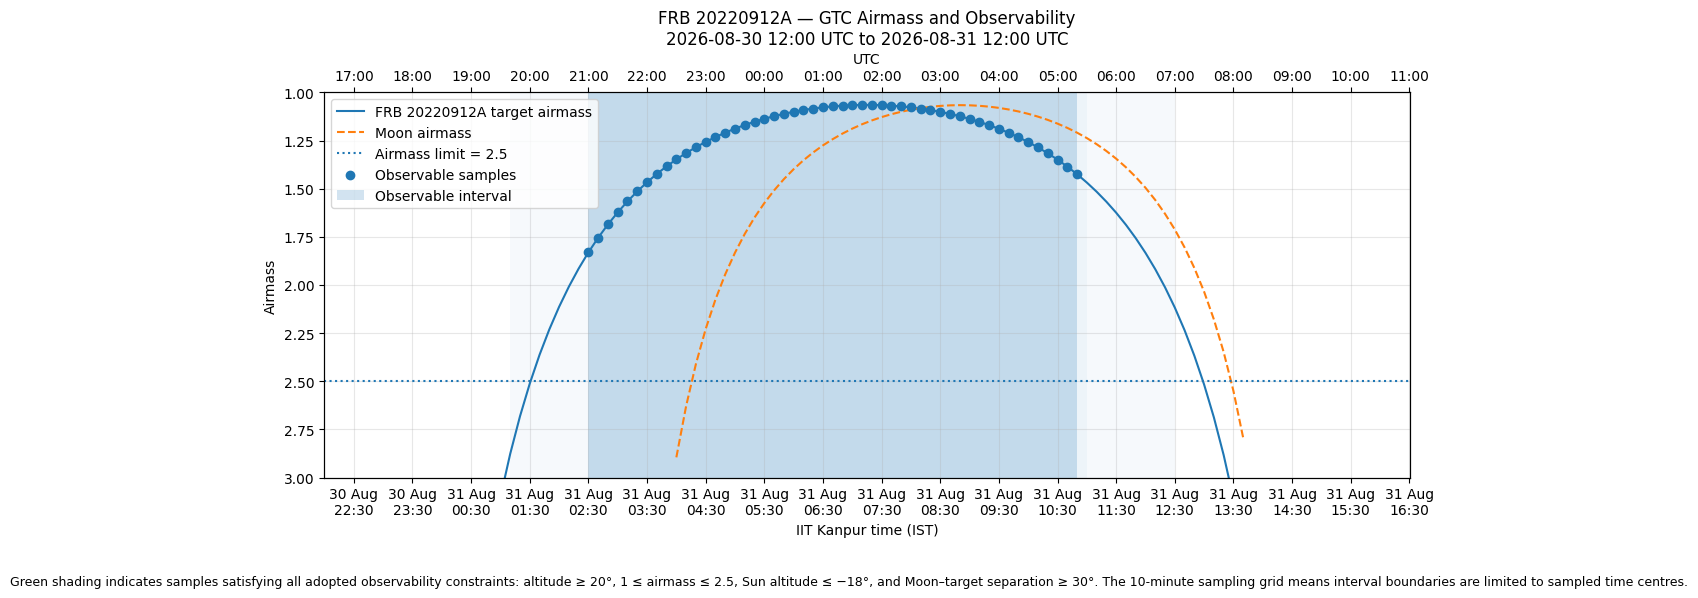

Saved figure to: assignment_outputs/frb_20220912a_gtc_airmass.png


In [20]:
def stitch_windows(times, visibility_state):
    visibility_state = np.asarray(visibility_state, dtype=bool)

    intervals = []
    start = None

    for i, visible in enumerate(visibility_state):

        if visible and start is None:
            start = i

        elif not visible and start is not None:
            intervals.append((start, i - 1))
            start = None

    if start is not None:
        intervals.append((start, len(visibility_state) - 1))

    return intervals

observable_intervals = stitch_windows(
    times,
    preferred_visibility
)

print("Number of observable intervals =", len(observable_intervals))

for start_idx, end_idx in observable_intervals:

    duration = (
        times[end_idx] - times[start_idx]
    ).to_value(u.min)

    midpoint_idx = (start_idx + end_idx) // 2

    print(
        "\nObservable interval:"
        f"\n  Start UTC = {format_utc(times[start_idx])}"
        f"\n  Start IST = {format_iitk(times[start_idx])}"
        f"\n  End UTC = {format_utc(times[end_idx])}"
        f"\n  End IST = {format_iitk(times[end_idx])}"
        f"\n  Sample-centre duration = {duration:.1f} min"
        f"\n  Best target airmass = "
        f"{np.nanmin(target_airmass[start_idx:end_idx+1])}"
        f"\n  Midpoint UTC = {format_utc(times[midpoint_idx])}"
        f"\n  Midpoint IST = {format_iitk(times[midpoint_idx])}"
        f"\n  Midpoint Moon label = {moon_label[midpoint_idx]}"
    )

times_utc_dt = [t.to_datetime(timezone=timezone.utc) for t in times]
times_ist_dt = [t.to_datetime(timezone=IITK_TIMEZONE) for t in times]
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(times_ist_dt, target_airmass, linestyle="-", label="FRB 20220912A target airmass")
ax.plot(times_ist_dt, moon_airmass, linestyle="--", label="Moon airmass")
ax.axhline(2.5, linestyle=":", label="Airmass limit = 2.5")
observable_indices = np.where(preferred_visibility)[0]
ax.scatter([times_ist_dt[i] for i in observable_indices], target_airmass[observable_indices], marker="o", label="Observable samples", zorder=5)
for start_idx, end_idx in observable_intervals:

    ax.axvspan(
        times_ist_dt[start_idx],
        times_ist_dt[end_idx],
        alpha=0.2,
        label="Observable interval"
        if start_idx == observable_intervals[0][0]
        else None
    )

sun_alt_deg = sun_altitude
night = sun_alt_deg <= -18
twilight = (sun_alt_deg > -18) & (sun_alt_deg <= 0)
for i in range(len(times) - 1):

    if night[i]:
        ax.axvspan(
            times_ist_dt[i],
            times_ist_dt[i + 1],
            alpha=0.08
        )

    elif twilight[i]:
        ax.axvspan(
            times_ist_dt[i],
            times_ist_dt[i + 1],
            alpha=0.04
        )

ax.set_ylabel("Airmass")
ax.set_xlabel("IIT Kanpur time (IST)")
ax.set_ylim(3, 1)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M", tz=IITK_TIMEZONE))
ax_utc = ax.twiny()
ax_utc.set_xlim(ax.get_xlim())
ax_utc.xaxis.set_major_locator(mdates.HourLocator(interval=1, tz=timezone.utc))
ax_utc.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=timezone.utc))
ax_utc.set_xlabel("UTC")
ax.set_title("FRB 20220912A — GTC Airmass and Observability\n" "2026-08-30 12:00 UTC to 2026-08-31 12:00 UTC")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

caption = (
    "Green shading indicates samples satisfying all adopted "
    "observability constraints: altitude ≥ 20°, 1 ≤ airmass ≤ 2.5, "
    "Sun altitude ≤ −18°, and Moon–target separation ≥ 30°. "
    "The 10-minute sampling grid means interval boundaries are "
    "limited to sampled time centres."
)

fig.text(
    0.5,
    0.01,
    caption,
    ha="center",
    va="bottom",
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.07, 1, 1]
)

output_file = (
    OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"
)

fig.savefig(
    output_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", output_file)

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [21]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
q19_start = Time("2026-09-01T00:00:00", scale="utc")
q19_stop = Time("2026-09-02T00:00:00", scale="utc")
q19_step = 10 * u.min
q19_n = int(((q19_stop - q19_start) / q19_step).value)
q19_times = (q19_start + np.arange(q19_n + 1) * q19_step)
q19_altaz = frb_icrs.transform_to(AltAz(obstime=q19_times, location=gtc_location))
q19_altitude = q19_altaz.alt
q19_airmass = q19_altaz.secz.to_value(u.dimensionless_unscaled)
q19_sun = get_sun(q19_times)
q19_sun_altaz = q19_sun.transform_to(AltAz(obstime=q19_times,location=gtc_location))
q19_sun_altitude = q19_sun_altaz.alt
q19_alt_ok = (q19_altitude >= 20 * u.deg)
q19_airmass_ok = (np.isfinite(q19_airmass) & (q19_airmass >= 1) & (q19_airmass <= 2.5))
q19_sun_ok = (q19_sun_altitude <= -18 * u.deg)
q19_visible = (q19_alt_ok & q19_airmass_ok & q19_sun_ok)
print("Altitude condition samples =", np.count_nonzero(q19_alt_ok))
print("Airmass condition samples =", np.count_nonzero(q19_airmass_ok))
print("Night condition samples =", np.count_nonzero(q19_sun_ok))
print("All conditions simultaneously =", np.count_nonzero(q19_visible))
print("Observable at any sample =", np.any(q19_visible))

Altitude condition samples = 1
Airmass condition samples = 1
Night condition samples = 1
All conditions simultaneously = 1
Observable at any sample = True


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

Number of weekly dates = 53
First date = 2026-08-30 00:00:00.000
Last date  = 2027-08-29 00:00:00.000
HEALPix NSIDE = 32
Number of HEALPix pixels = 12288
Processing 1/53: 2026-08-30
    Observable sky = 56.63%


/usr/local/lib/python3.13/dist-packages/healpy/visufunc.py:1647: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


Processing 2/53: 2026-09-06
    Observable sky = 58.25%
Processing 3/53: 2026-09-13
    Observable sky = 58.34%
Processing 4/53: 2026-09-20
    Observable sky = 59.97%
Processing 5/53: 2026-09-27
    Observable sky = 60.01%
Processing 6/53: 2026-10-04
    Observable sky = 59.95%
Processing 7/53: 2026-10-11
    Observable sky = 59.97%
Processing 8/53: 2026-10-18
    Observable sky = 61.65%
Processing 9/53: 2026-10-25
    Observable sky = 61.62%
Processing 10/53: 2026-11-01
    Observable sky = 63.31%
Processing 11/53: 2026-11-08
    Observable sky = 63.31%
Processing 12/53: 2026-11-15
    Observable sky = 63.33%
Processing 13/53: 2026-11-22
    Observable sky = 63.32%
Processing 14/53: 2026-11-29
    Observable sky = 63.30%
Processing 15/53: 2026-12-06
    Observable sky = 63.31%
Processing 16/53: 2026-12-13
    Observable sky = 64.93%
Processing 17/53: 2026-12-20
    Observable sky = 64.99%
Processing 18/53: 2026-12-27
    Observable sky = 64.96%
Processing 19/53: 2027-01-03
    Observ

Processing 52/53: 2027-08-22
    Observable sky = 54.94%
Processing 53/53: 2027-08-29
    Observable sky = 56.63%
Number of PNG frames = 53
GIF exists = True
GIF size = 586223 bytes
First observable fraction = 56.63%
Last observable fraction = 56.63%
GIF path = assignment_outputs/q20_gtc_all_sky_visibility.gif


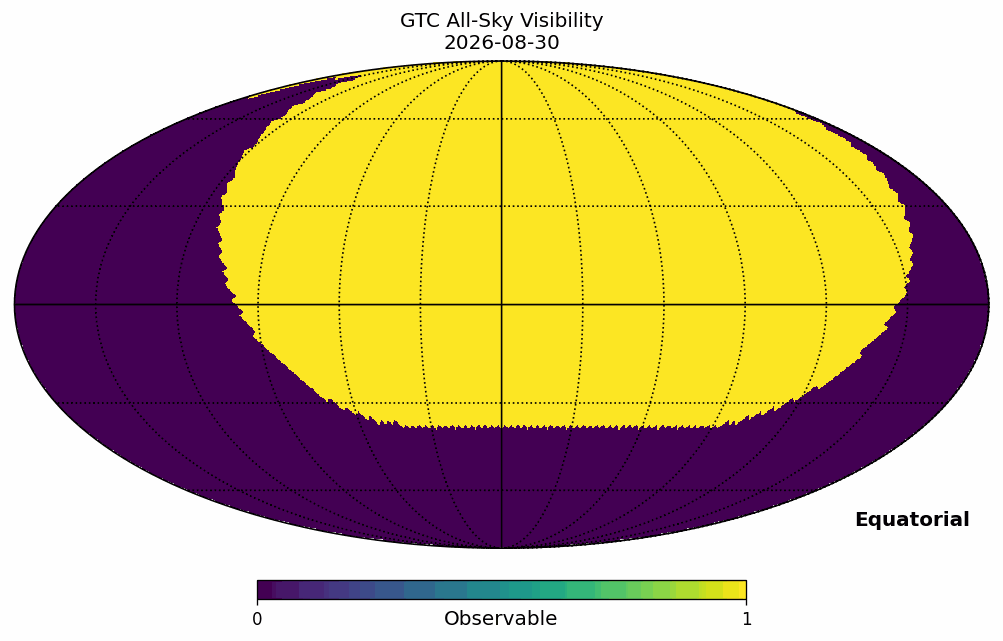

In [25]:
import healpy as hp
import imageio.v2 as imageio

from pathlib import Path
from IPython.display import Image, display
q20_start = Time("2026-08-30T00:00:00", scale="utc")
q20_end = Time("2027-08-29T00:00:00", scale="utc")
q20_times = (q20_start + np.arange(int(((q20_end - q20_start) / (7 * u.day)).value) + 1) * 7 * u.day)

print("Number of weekly dates =", len(q20_times))
print("First date =", q20_times[0].iso)
print("Last date  =", q20_times[-1].iso)

NSIDE = 32
npix = hp.nside2npix(NSIDE)
pixel_numbers = np.arange(npix)
theta, phi = hp.pix2ang( NSIDE, pixel_numbers)
sky_ra = phi * u.rad
sky_dec = ((np.pi / 2 - theta) * u.rad)
all_sky = SkyCoord(
    ra=sky_ra,
    dec=sky_dec,
    frame="icrs"
)

print("HEALPix NSIDE =", NSIDE)
print("Number of HEALPix pixels =", npix)
q20_output_dir = (OUTPUT_DIR / "q20_frames")
q20_output_dir.mkdir( parents=True, exist_ok=True)
gif_file = (OUTPUT_DIR/ "q20_gtc_all_sky_visibility.gif")
gif_frames = []
observable_fractions = []
for date_number, current_date in enumerate(q20_times):

    date_string = current_date.iso[:10]

    print(f"Processing {date_number + 1}/{len(q20_times)}: " f"{date_string}")

    day_start = Time(date_string + "T00:00:00", scale="utc")
    day_times = (day_start + np.arange(49) * 30 * u.min)
    sun = get_sun(day_times)
    sun_altaz = sun.transform_to(AltAz( obstime=day_times, location=gtc_location))
    sun_altitude = (sun_altaz.alt.to_value(u.deg))
    night_ok = (sun_altitude <= -18.0)

    altitude_grid = np.empty((len(day_times), npix))
    airmass_grid = np.empty((len(day_times), npix))
    for j, current_time in enumerate(day_times):

        sky_altaz = all_sky.transform_to(AltAz(obstime=current_time, location=gtc_location))
        altitude_grid[j, :] = (sky_altaz.alt.to_value(u.deg))
        airmass_grid[j, :] = (sky_altaz.secz.to_value(u.dimensionless_unscaled))

    altitude_ok = (altitude_grid >= 20.0)
    airmass_ok = (
        np.isfinite(airmass_grid)
        & (airmass_grid >= 1.0)
        & (airmass_grid <= 2.5))

    visible_at_time = (
        altitude_ok
        & airmass_ok
        & night_ok[:, None]
    )

    visibility_map = np.any(visible_at_time, axis=0)
    fraction = np.mean(visibility_map)
    observable_fractions.append(fraction)
    print(f"    Observable sky = " f"{100 * fraction:.2f}%")
    hp.mollview(
        visibility_map.astype(float),
        title=(
            "GTC All-Sky Visibility\n"
            f"{date_string}"
        ),
        coord="C",
        unit="Observable",
        min=0,
        max=1,
        cmap="viridis",
        cbar=True
    )

    hp.graticule(verbose=False)
    frame_file = (
        q20_output_dir
        / f"frame_{date_number:03d}.png"
    )

    plt.savefig(
        frame_file,
        dpi=120,
        bbox_inches="tight"
    )

    plt.close()




    gif_frames.append(
        imageio.imread(frame_file)
    )

imageio.mimsave(
    gif_file,
    gif_frames,
    duration=0.25,
    loop=0
)

png_files = sorted(q20_output_dir.glob("*.png"))
print("Number of PNG frames =", len(png_files))
print("GIF exists =", gif_file.exists())
print("GIF size =", gif_file.stat().st_size, "bytes")
print("First observable fraction =", f"{100 * observable_fractions[0]:.2f}%")
print("Last observable fraction =", f"{100 * observable_fractions[-1]:.2f}%")
print("GIF path =", gif_file)
display(Image(filename=str(gif_file) ))

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
